# Bitcoin Market Analysis & Quantitative Strategy Evaluation

**Versão 2.0** — Refatorada com funções reutilizáveis, métricas aprimoradas e correlação rolling.

---
### Estrutura do Notebook
1. Setup & Aquisição de Dados
2. Análise Exploratória (EDA)
3. Backtesting — Cruzamento de Médias Móveis
4. Otimização de Parâmetros
5. Backtest Robusto com Custos de Transação
6. Estratégia com Trailing Stop-Loss
7. Estratégia Intradiária (Bandas de Bollinger)
8. Correlação Rolling: BTC vs S&P 500

## 1. Setup & Aquisição de Dados

In [1]:
# ── Bloco 1: Instalação e Importações ────────────────────────────────────────
# Instala dependências caso necessário (compatível com Colab e ambiente local)
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'yfinance', '-q'])

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# ── Estilo Global ─────────────────────────────────────────────────────────────
sns.set_style('darkgrid')
plt.rcParams.update({
    'figure.figsize': (14, 6),
    'axes.titlesize': 15,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
})

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


In [2]:
# ── Bloco 2: Aquisição e Preparação dos Dados ─────────────────────────────────
BTC_TICKER   = 'BTC-USD'
SP500_TICKER = '^GSPC'
TRADING_DAYS = 252  # dias de trading em um ano

print(f'Baixando dados históricos para {BTC_TICKER} e {SP500_TICKER}...')

data_raw = yf.download(
    [BTC_TICKER, SP500_TICKER],
    period='max',
    interval='1d',
    auto_adjust=True,
    progress=False,
)

if data_raw.empty:
    raise RuntimeError('Nenhum dado baixado. Verifique sua conexão ou os tickers.')

# ── Extração e limpeza das séries de preços de fechamento ─────────────────────
# Seleciona colunas pelo nome do ticker (evita problema de ordem de colunas
# no yfinance) e garante que datas sem dados do BTC sejam removidas
close = pd.DataFrame({
    'BTC'  : data_raw['Close'][BTC_TICKER],
    'SP500': data_raw['Close'][SP500_TICKER],
})

# Remove linhas onde qualquer valor é NaN ou zero (yfinance às vezes retorna
# 0 para datas sem dados, o que dropna() não capturaria)
close = close.replace(0, float('nan')).dropna()

# ── Séries de retornos diários ────────────────────────────────────────────────
returns = close.pct_change().dropna()
returns.columns = ['BTC_ret', 'SP500_ret']

print(f'Dados carregados: {close.index[0].date()} → {close.index[-1].date()} '
      f'({len(close):,} dias)')
print(f'Período BTC validado: sem datas pré-2010 ou valores zerados.')
close.tail(3)


Baixando dados históricos para BTC-USD e ^GSPC...
Dados carregados: 2014-09-17 → 2026-03-20 (2,894 dias)
Período BTC validado: sem datas pré-2010 ou valores zerados.


,BTC,SP500
Date,,
2026-03-18,71245.578125,6624.700195
2026-03-19,69912.789062,6606.490234
2026-03-20,70522.585938,6506.479980


## 2. Análise Exploratória (EDA)

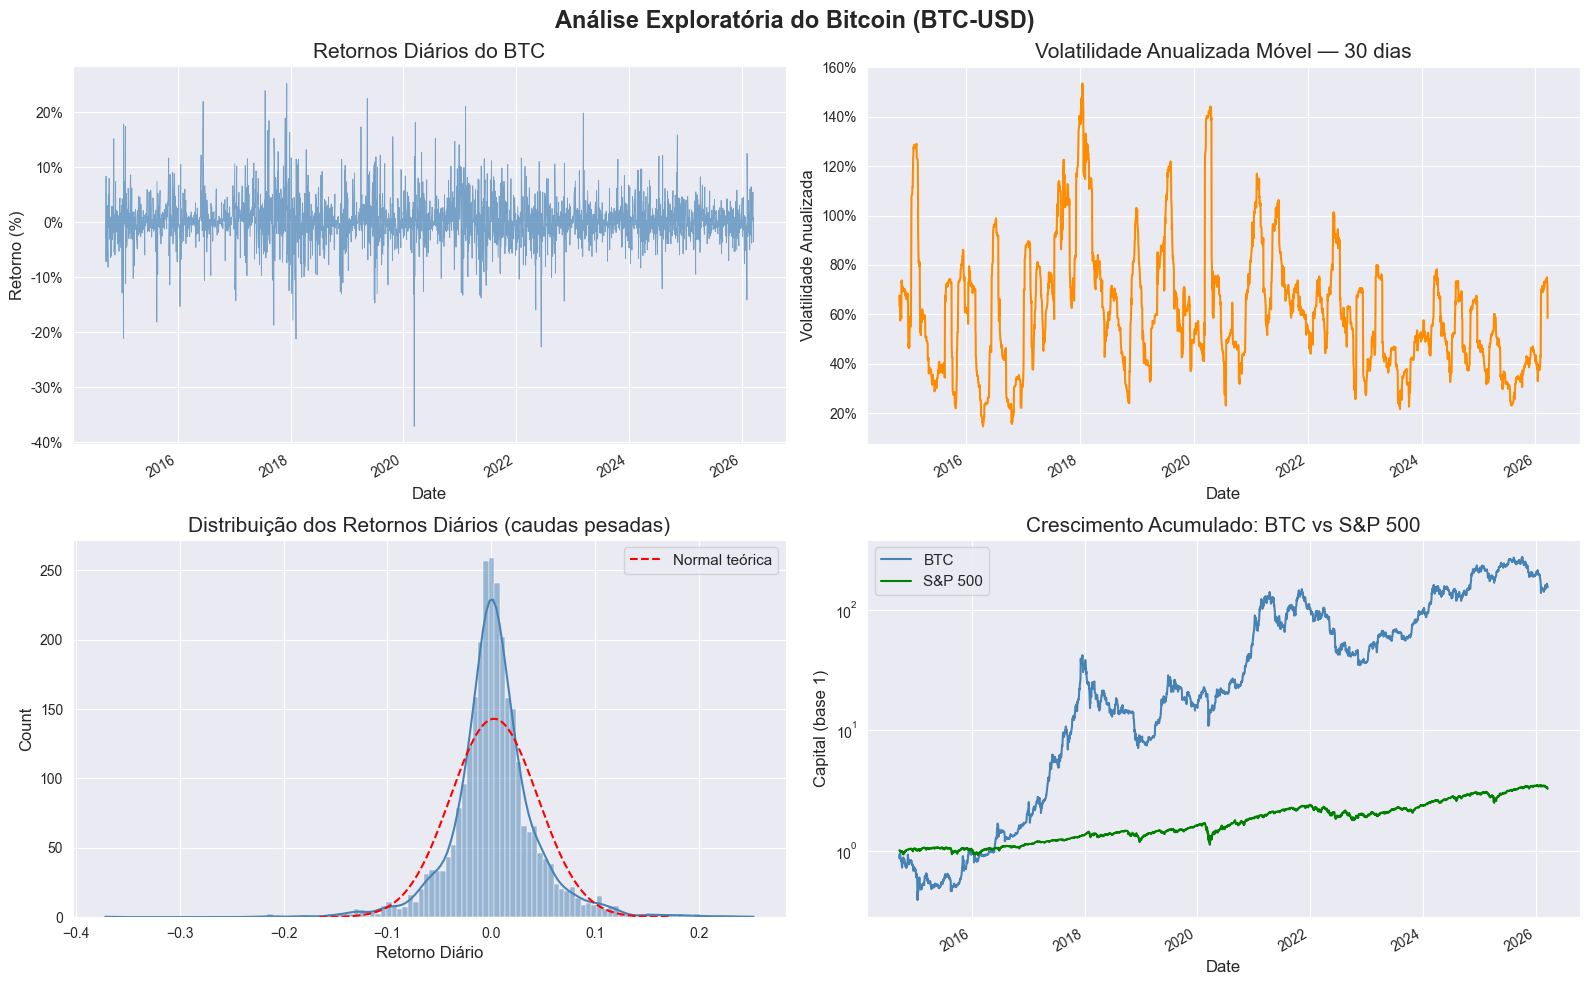


── Estatísticas Descritivas dos Retornos Diários ──
               mean       std  ann_return   ann_vol    sharpe
BTC_ret    0.002629  0.042001    0.938180  0.666747  1.407101
SP500_ret  0.000470  0.011171    0.125749  0.177326  0.709141


In [3]:
# ── Bloco 3: EDA — Retornos, Volatilidade e Distribuição ─────────────────────

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Análise Exploratória do Bitcoin (BTC-USD)', fontsize=17, fontweight='bold')

# 1. Retornos diários
ax = axes[0, 0]
returns['BTC_ret'].plot(ax=ax, color='steelblue', alpha=0.7, linewidth=0.6)
ax.set_title('Retornos Diários do BTC')
ax.set_ylabel('Retorno (%)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# 2. Volatilidade Móvel (30 dias)
ax = axes[0, 1]
vol_30 = returns['BTC_ret'].rolling(30).std() * np.sqrt(TRADING_DAYS)
vol_30.plot(ax=ax, color='darkorange')
ax.set_title('Volatilidade Anualizada Móvel — 30 dias')
ax.set_ylabel('Volatilidade Anualizada')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# 3. Distribuição dos retornos
ax = axes[1, 0]
sns.histplot(returns['BTC_ret'], bins=120, ax=ax, color='steelblue', kde=True)
# Linha de distribuição normal para comparação
mu, sigma = returns['BTC_ret'].mean(), returns['BTC_ret'].std()
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
from scipy.stats import norm
pdf_normal = norm.pdf(x, mu, sigma) * len(returns) * (returns['BTC_ret'].max() - returns['BTC_ret'].min()) / 120
ax.plot(x, pdf_normal, 'r--', label='Normal teórica')
ax.set_title('Distribuição dos Retornos Diários (caudas pesadas)')
ax.set_xlabel('Retorno Diário')
ax.legend()

# 4. Crescimento acumulado BTC vs S&P 500
ax = axes[1, 1]
cumulative = (1 + returns).cumprod()
cumulative['BTC_ret'].plot(ax=ax, label='BTC', color='steelblue')
cumulative['SP500_ret'].plot(ax=ax, label='S&P 500', color='green')
ax.set_title('Crescimento Acumulado: BTC vs S&P 500')
ax.set_ylabel('Capital (base 1)')
ax.set_yscale('log')
ax.legend()

plt.tight_layout()
plt.show()

# ── Estatísticas descritivas ──────────────────────────────────────────────────
print('\n── Estatísticas Descritivas dos Retornos Diários ──')
stats = returns.describe().T
stats['ann_return'] = (1 + stats['mean'])**TRADING_DAYS - 1
stats['ann_vol']    = stats['std'] * np.sqrt(TRADING_DAYS)
stats['sharpe']     = stats['ann_return'] / stats['ann_vol']
print(stats[['mean','std','ann_return','ann_vol','sharpe']].to_string())

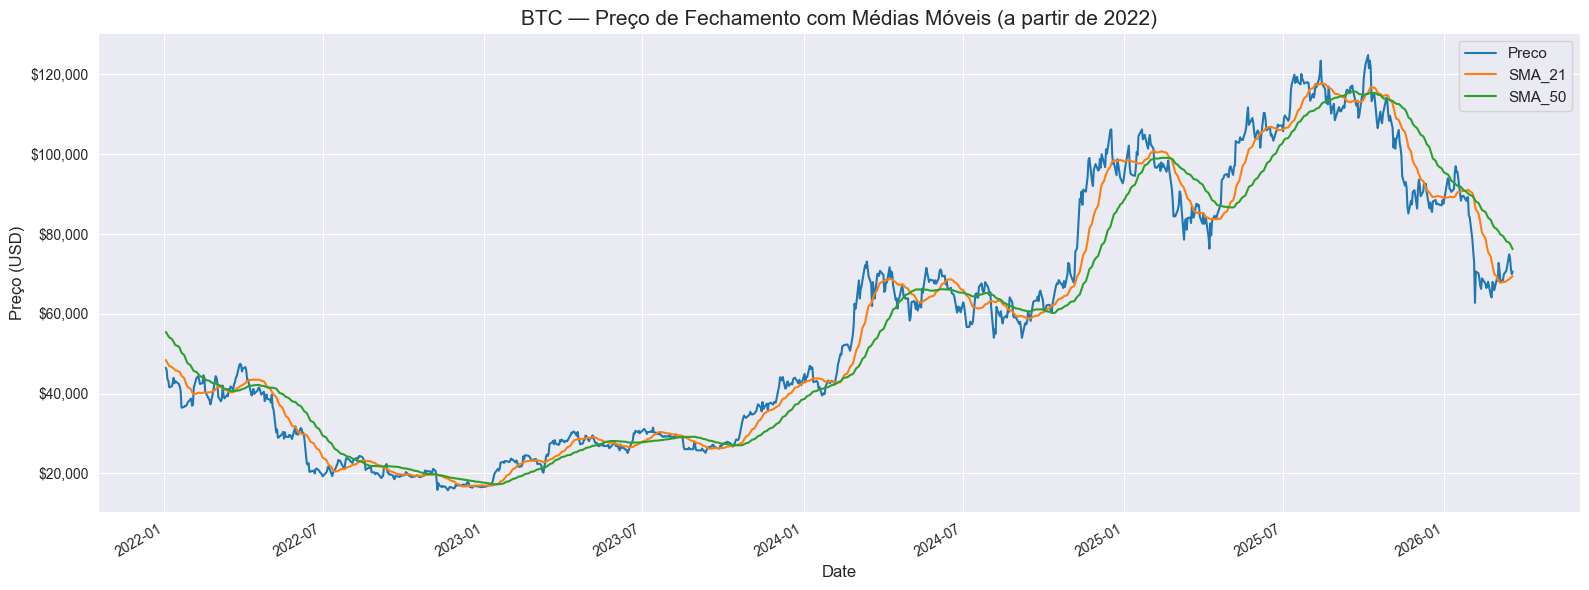

In [4]:
# ── Bloco 3b: Médias Móveis — Identificação de Regimes ───────────────────────
df_btc = pd.DataFrame({'Preco': close['BTC']})
df_btc['SMA_21'] = df_btc['Preco'].rolling(21).mean()
df_btc['SMA_50'] = df_btc['Preco'].rolling(50).mean()

fig, ax = plt.subplots(figsize=(16, 6))
df_btc.loc['2022':, ['Preco', 'SMA_21', 'SMA_50']].plot(ax=ax)
ax.set_title('BTC — Preço de Fechamento com Médias Móveis (a partir de 2022)')
ax.set_ylabel('Preço (USD)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 3–6. Backtesting

> **Nota de design:** a função `run_backtest()` abaixo centraliza toda a lógica de backtest,
> eliminando a duplicação que existia nas versões anteriores do notebook.

In [5]:
# ── Bloco 4: Função Central de Backtest (reutilizável) ────────────────────────

def run_backtest(
    prices: pd.Series,
    short_win: int = 10,
    long_win: int  = 30,
    cost_bps: float = 0.001,      # custo por transação (0.1%)
    trailing_stop: float = None,  # ex: 0.15 para 15% trailing stop; None = desativado
    label: str = None,
    plot: bool = True,
) -> dict:
    """
    Executa um backtest de cruzamento de médias móveis (SMA crossover).

    Parâmetros
    ----------
    prices        : pd.Series com preços diários de fechamento.
    short_win     : janela da SMA curta.
    long_win      : janela da SMA longa.
    cost_bps      : custo por trade (ex: 0.001 = 0.1%).
    trailing_stop : percentual do trailing stop. None desativa.
    label         : rótulo para os gráficos.
    plot          : se True, exibe o gráfico de performance.

    Retorna
    -------
    dict com métricas e o DataFrame de resultado.
    """
    df = pd.DataFrame({'Preco': prices.copy()})
    df.dropna(inplace=True)

    sma_s = f'SMA_{short_win}'
    sma_l = f'SMA_{long_win}'
    df[sma_s] = df['Preco'].rolling(short_win).mean()
    df[sma_l] = df['Preco'].rolling(long_win).mean()
    df.dropna(inplace=True)

    # ── Geração de sinais vetorizada ──────────────────────────────────────────
    above     = df[sma_s] > df[sma_l]
    above_lag = above.shift(1).fillna(False)
    golden_cross = above  & ~above_lag   # SMA curta cruza para cima
    death_cross  = ~above &  above_lag   # SMA curta cruza para baixo

    df['Sinal'] = 0
    df.loc[golden_cross, 'Sinal'] =  1
    df.loc[death_cross,  'Sinal'] = -1

    # ── Posição com ou sem Trailing Stop ──────────────────────────────────────
    if trailing_stop is None:
        # Posição vetorizada (sem trailing stop)
        df['Posicao'] = (
            df['Sinal']
            .replace(0, np.nan)
            .ffill()
            .fillna(0)
            .replace(-1, 0)
            .shift(1)
            .fillna(0)
        )
    else:
        # Posição com trailing stop (loop necessário por ser path-dependent)
        posicoes = []
        pos = 0
        pico = 0.0
        stop = 0.0
        for _, row in df.iterrows():
            if pos == 0 and row['Sinal'] == 1:
                pos  = 1
                pico = row['Preco']
                stop = pico * (1 - trailing_stop)
            elif pos == 1:
                if row['Preco'] > pico:
                    pico = row['Preco']
                    stop = pico * (1 - trailing_stop)
                if row['Sinal'] == -1 or row['Preco'] < stop:
                    pos  = 0
                    pico = 0.0
                    stop = 0.0
            posicoes.append(pos)
        df['Posicao'] = pd.Series(posicoes, index=df.index).shift(1).fillna(0)

    # ── Retornos ──────────────────────────────────────────────────────────────
    df['Ret_Diario']    = df['Preco'].pct_change()
    df['Custo']         = df['Posicao'].diff().abs() * cost_bps
    df['Ret_Estrategia'] = df['Ret_Diario'] * df['Posicao'] - df['Custo']
    df.dropna(inplace=True)

    df['Equity_Strat'] = (1 + df['Ret_Estrategia']).cumprod()
    df['Equity_BH']    = (1 + df['Ret_Diario']).cumprod()

    # ── Métricas ──────────────────────────────────────────────────────────────
    n = len(df)

    def _metrics(equity_curve, ret_series):
        total   = equity_curve.iloc[-1]
        ann_ret = total**(TRADING_DAYS / n) - 1
        ann_vol = ret_series.std() * np.sqrt(TRADING_DAYS)
        sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan

        # Sortino: penaliza apenas volatilidade negativa
        downside_vol = ret_series[ret_series < 0].std() * np.sqrt(TRADING_DAYS)
        sortino = ann_ret / downside_vol if downside_vol > 0 else np.nan

        # Max Drawdown
        dd = (equity_curve - equity_curve.cummax()) / equity_curve.cummax()
        max_dd = dd.min()

        # Calmar Ratio
        calmar = ann_ret / abs(max_dd) if max_dd != 0 else np.nan

        # Exposição ao mercado
        exposure = (df['Posicao'] > 0).mean()

        return dict(
            total=total, ann_ret=ann_ret, ann_vol=ann_vol,
            sharpe=sharpe, sortino=sortino, max_dd=max_dd,
            calmar=calmar, exposure=exposure,
        )

    m_strat = _metrics(df['Equity_Strat'], df['Ret_Estrategia'])
    m_bh    = _metrics(df['Equity_BH'],    df['Ret_Diario'])

    n_buys  = (df['Sinal'] ==  1).sum()
    n_sells = (df['Sinal'] == -1).sum()

    lbl = label or f'SMA {short_win}/{long_win}'
    ts_tag = f' + Trailing Stop {trailing_stop:.0%}' if trailing_stop else ' + Custos'

    # ── Tabela de métricas ────────────────────────────────────────────────────
    print(f'\n══ Métricas: {lbl}{ts_tag} ══')
    rows = [
        ('Retorno Total',          f"{m_strat['total']:.2f}x",          f"{m_bh['total']:.2f}x"),
        ('Retorno Anualizado',     f"{m_strat['ann_ret']:.2%}",          f"{m_bh['ann_ret']:.2%}"),
        ('Volatilidade Anualizada',f"{m_strat['ann_vol']:.2%}",          f"{m_bh['ann_vol']:.2%}"),
        ('Sharpe Ratio',           f"{m_strat['sharpe']:.2f}",           f"{m_bh['sharpe']:.2f}"),
        ('Sortino Ratio',          f"{m_strat['sortino']:.2f}",          f"{m_bh['sortino']:.2f}"),
        ('Drawdown Máximo',        f"{m_strat['max_dd']:.2%}",           f"{m_bh['max_dd']:.2%}"),
        ('Calmar Ratio',           f"{m_strat['calmar']:.2f}",           f"{m_bh['calmar']:.2f}"),
        ('Exposição ao Mercado',   f"{m_strat['exposure']:.1%}",         'N/A (sempre 100%)'),
        ('Nº de Trades (C/V)',     f'{n_buys}/{n_sells}',                '—'),
    ]
    header = f"{'Métrica':<30} {'Estratégia':>20} {'Buy & Hold':>20}"
    print(header)
    print('─' * len(header))
    for r in rows:
        print(f'{r[0]:<30} {r[1]:>20} {r[2]:>20}')

    # ── Gráfico de performance ────────────────────────────────────────────────
    if plot:
        fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                                 gridspec_kw={'height_ratios': [3, 1]})

        # Equity curves
        df['Equity_Strat'].plot(ax=axes[0], label=f'{lbl}{ts_tag}', color='steelblue')
        df['Equity_BH'].plot(ax=axes[0], label='Buy & Hold', color='darkorange', alpha=0.8)
        axes[0].set_title(f'Performance: {lbl}{ts_tag} vs Buy & Hold', fontsize=15)
        axes[0].set_ylabel('Capital (base 1, escala log)')
        axes[0].set_yscale('log')
        axes[0].legend()

        # Drawdown
        dd_strat = (df['Equity_Strat'] - df['Equity_Strat'].cummax()) / df['Equity_Strat'].cummax()
        dd_strat.plot(ax=axes[1], color='steelblue', alpha=0.7)
        axes[1].fill_between(dd_strat.index, dd_strat, 0, alpha=0.2, color='steelblue')
        axes[1].set_ylabel('Drawdown')
        axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

        plt.tight_layout()
        plt.show()

    return {'metrics_strat': m_strat, 'metrics_bh': m_bh, 'df': df, 'label': lbl}


print('✅ Função run_backtest() definida.')

✅ Função run_backtest() definida.


## 3. Backtest Base — SMA 21/50


══ Métricas: SMA 21/50 + Custos ══
Métrica                                  Estratégia           Buy & Hold
────────────────────────────────────────────────────────────────────────
Retorno Total                                79.11x              187.89x
Retorno Anualizado                           47.30%               59.03%
Volatilidade Anualizada                      52.52%               66.56%
Sharpe Ratio                                   0.90                 0.89
Sortino Ratio                                  0.95                 1.21
Drawdown Máximo                             -67.32%              -83.04%
Calmar Ratio                                   0.70                 0.71
Exposição ao Mercado                          57.1%    N/A (sempre 100%)
Nº de Trades (C/V)                          1625/29                    —


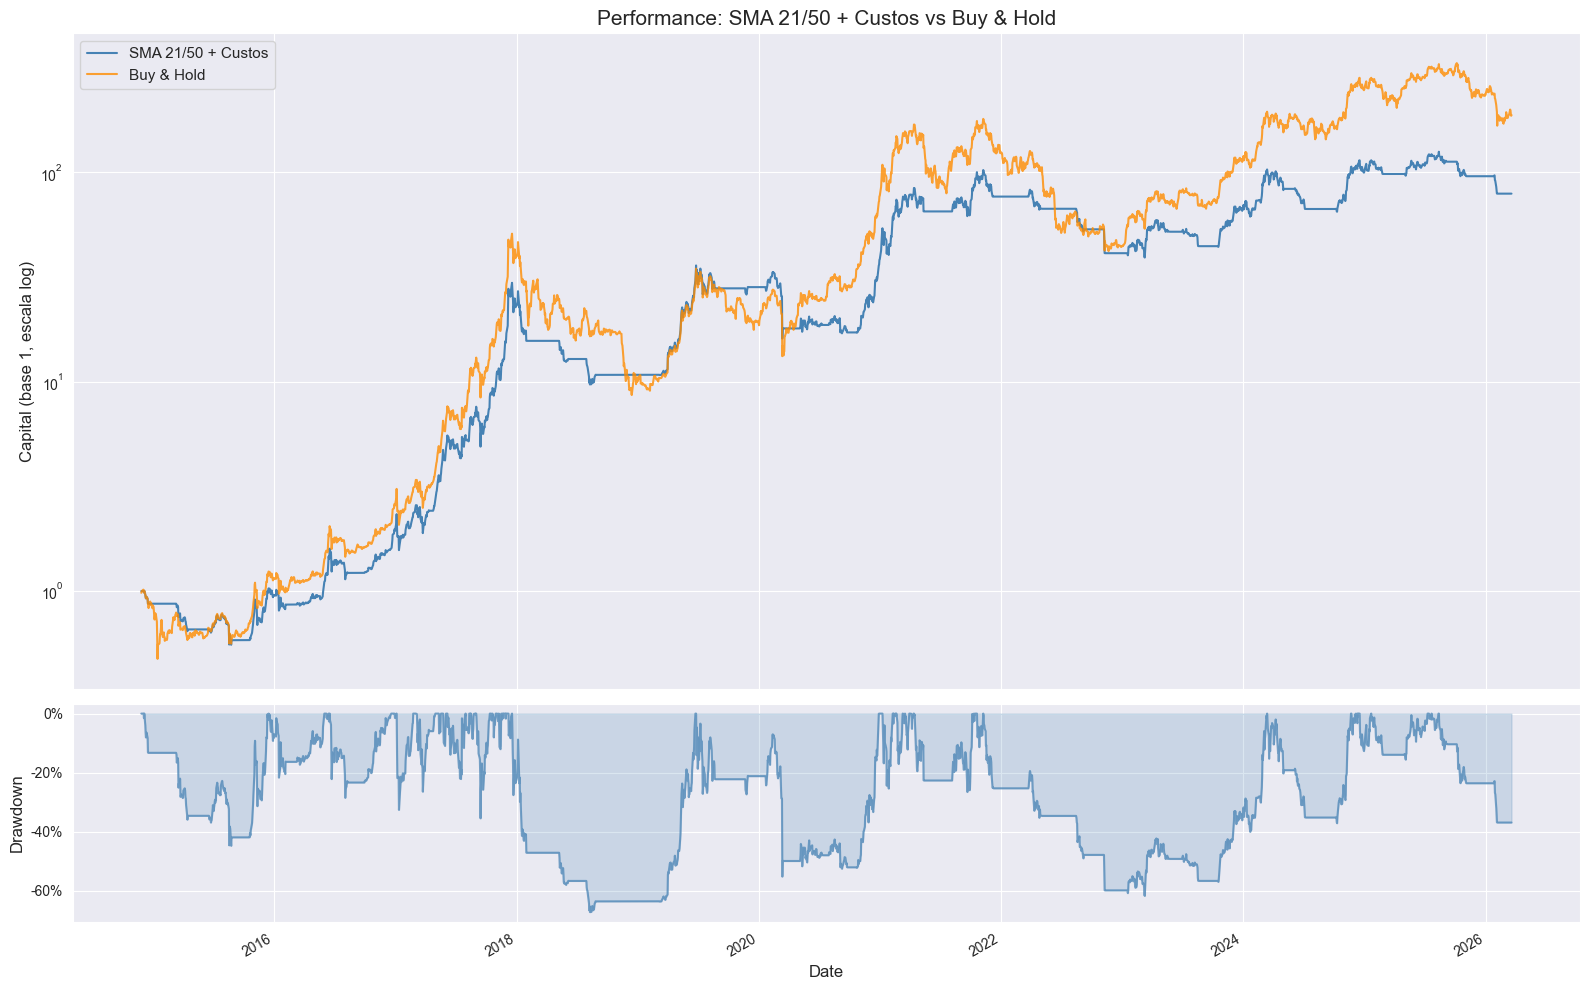

In [6]:
# ── Bloco 5: Backtest base ────────────────────────────────────────────────────
result_base = run_backtest(close['BTC'], short_win=21, long_win=50, label='SMA 21/50')

## 4. Otimização de Parâmetros

In [7]:
# ── Bloco 6: Otimização — grade de combinações SMA ────────────────────────────
combos = [(10, 30), (21, 50), (50, 200)]
summary = []

for short, long in combos:
    r = run_backtest(close['BTC'], short_win=short, long_win=long, plot=False)
    m = r['metrics_strat']
    summary.append({
        'Combinação'              : f'SMA {short}/{long}',
        'Retorno Total'           : f"{m['total']:.2f}x",
        'Retorno Anualizado'      : f"{m['ann_ret']:.2%}",
        'Volatilidade Anualizada' : f"{m['ann_vol']:.2%}",
        'Sharpe'                  : f"{m['sharpe']:.2f}",
        'Sortino'                 : f"{m['sortino']:.2f}",
        'Drawdown Máximo'         : f"{m['max_dd']:.2%}",
        'Calmar'                  : f"{m['calmar']:.2f}",
        'Exposição'               : f"{m['exposure']:.1%}",
    })

df_opt = pd.DataFrame(summary)
print('\n── Tabela Comparativa de Combinações SMA ──')
print(df_opt.to_string(index=False))


══ Métricas: SMA 10/30 + Custos ══
Métrica                                  Estratégia           Buy & Hold
────────────────────────────────────────────────────────────────────────
Retorno Total                               360.23x              197.20x
Retorno Anualizado                           67.86%               59.19%
Volatilidade Anualizada                      49.22%               66.66%
Sharpe Ratio                                   1.38                 0.89
Sortino Ratio                                  1.56                 1.21
Drawdown Máximo                             -68.27%              -83.04%
Calmar Ratio                                   0.99                 0.71
Exposição ao Mercado                          56.5%    N/A (sempre 100%)
Nº de Trades (C/V)                          1618/48                    —

══ Métricas: SMA 21/50 + Custos ══
Métrica                                  Estratégia           Buy & Hold
────────────────────────────────────────────────────

## 5. Backtest Robusto com Custos — SMA 10/30


══ Métricas: SMA 10/30 + Custos ══
Métrica                                  Estratégia           Buy & Hold
────────────────────────────────────────────────────────────────────────
Retorno Total                               360.23x              197.20x
Retorno Anualizado                           67.86%               59.19%
Volatilidade Anualizada                      49.22%               66.66%
Sharpe Ratio                                   1.38                 0.89
Sortino Ratio                                  1.56                 1.21
Drawdown Máximo                             -68.27%              -83.04%
Calmar Ratio                                   0.99                 0.71
Exposição ao Mercado                          56.5%    N/A (sempre 100%)
Nº de Trades (C/V)                          1618/48                    —


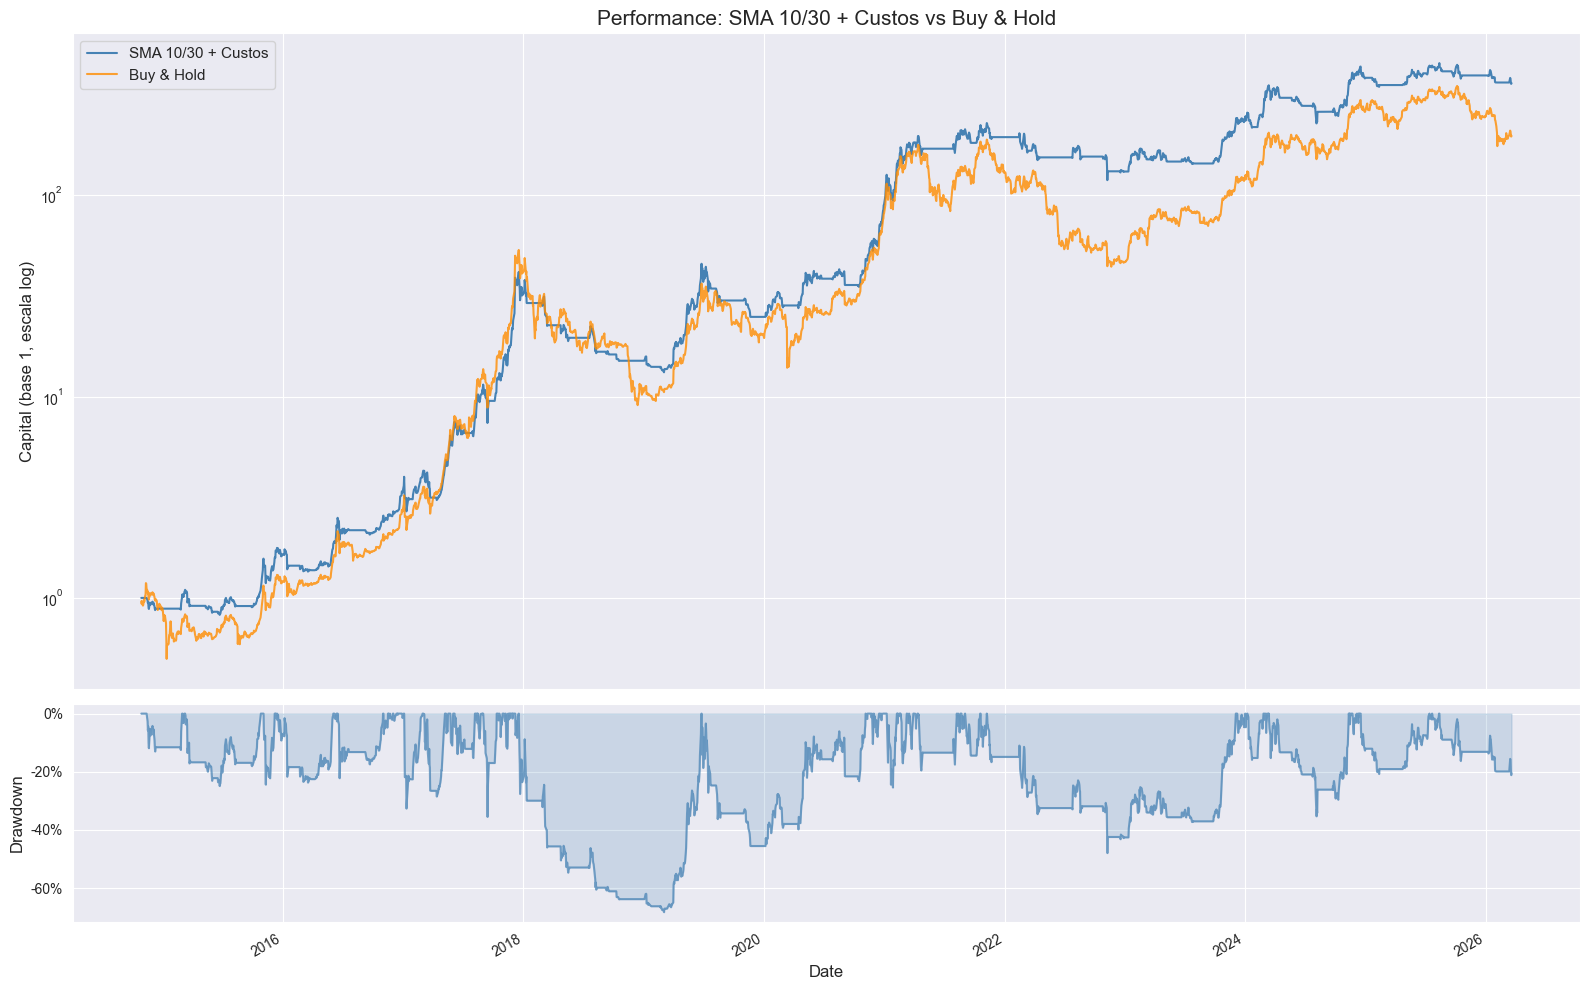

In [8]:
# ── Bloco 7: Backtest robusto com custos de transação ─────────────────────────
result_robust = run_backtest(
    close['BTC'],
    short_win=10, long_win=30,
    cost_bps=0.001,
    label='SMA 10/30',
)

## 6. Estratégia com Trailing Stop-Loss — SMA 10/30 + 15%


══ Métricas: SMA 10/30 + Trailing Stop 15% ══
Métrica                                  Estratégia           Buy & Hold
────────────────────────────────────────────────────────────────────────
Retorno Total                               201.96x              197.20x
Retorno Anualizado                           59.53%               59.19%
Volatilidade Anualizada                      48.33%               66.66%
Sharpe Ratio                                   1.23                 0.89
Sortino Ratio                                  1.39                 1.21
Drawdown Máximo                             -65.81%              -83.04%
Calmar Ratio                                   0.90                 0.71
Exposição ao Mercado                          55.5%    N/A (sempre 100%)
Nº de Trades (C/V)                          1618/48                    —


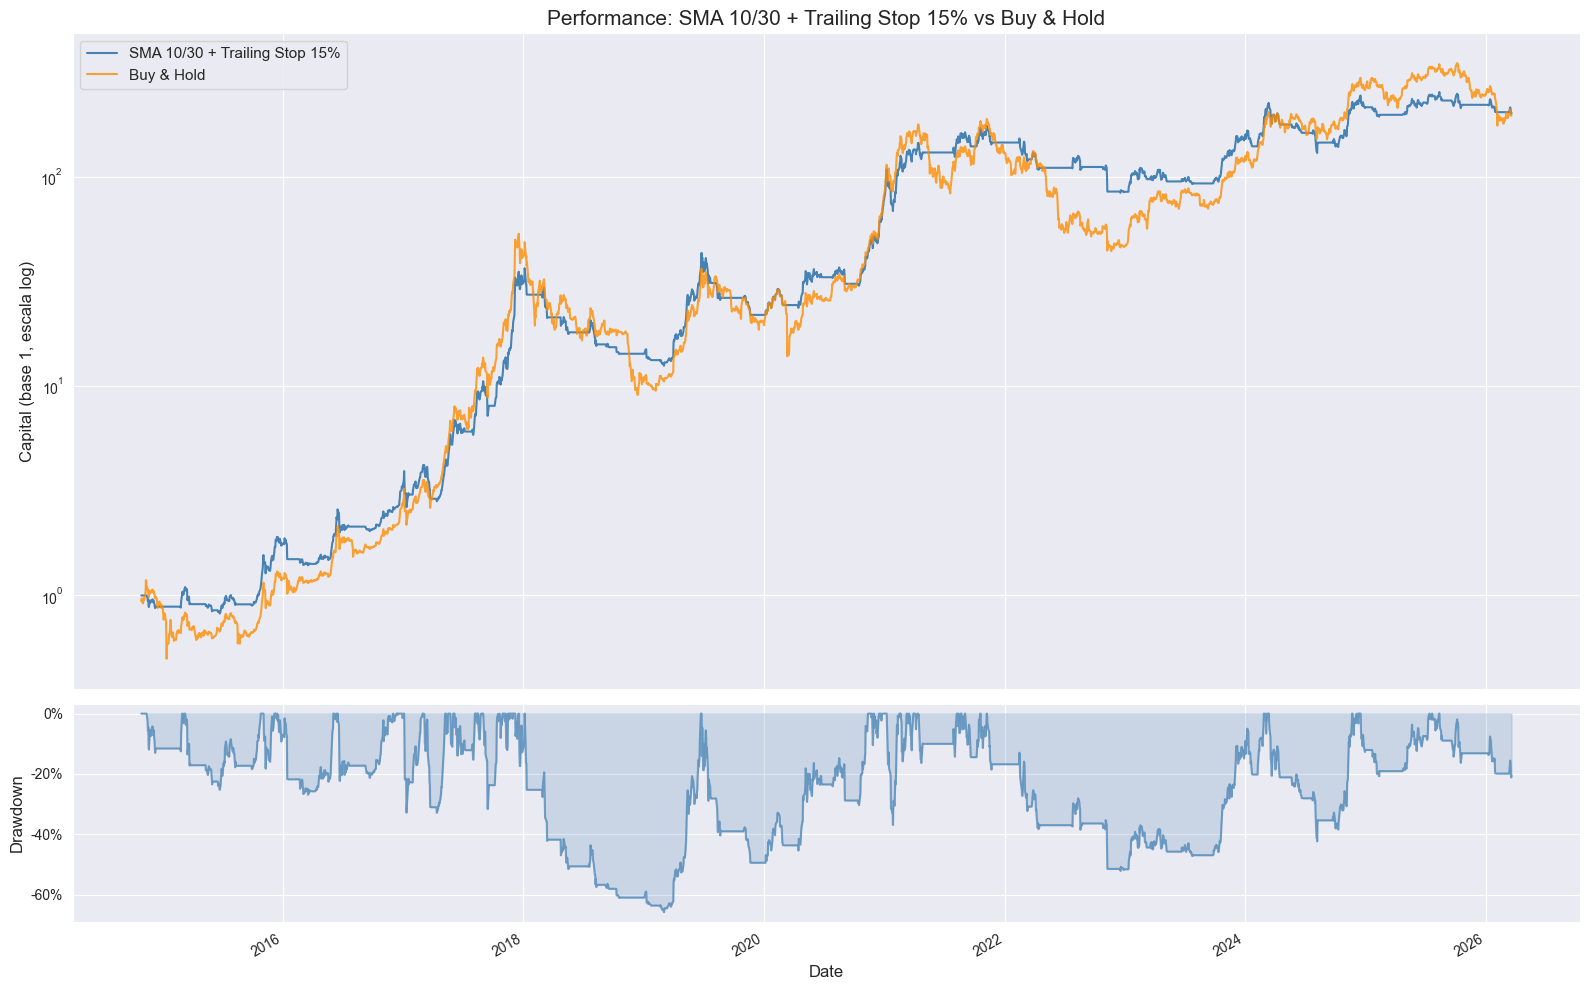

In [9]:
# ── Bloco 8: Backtest com trailing stop-loss ──────────────────────────────────
result_trail = run_backtest(
    close['BTC'],
    short_win=10, long_win=30,
    cost_bps=0.001,
    trailing_stop=0.15,
    label='SMA 10/30',
)

## 7. Estratégia Intradiária — Bandas de Bollinger (1h)

Baixando dados intradiários de 1 hora (últimos 60 dias)...
✅ 1,413 candles de 1h baixados.


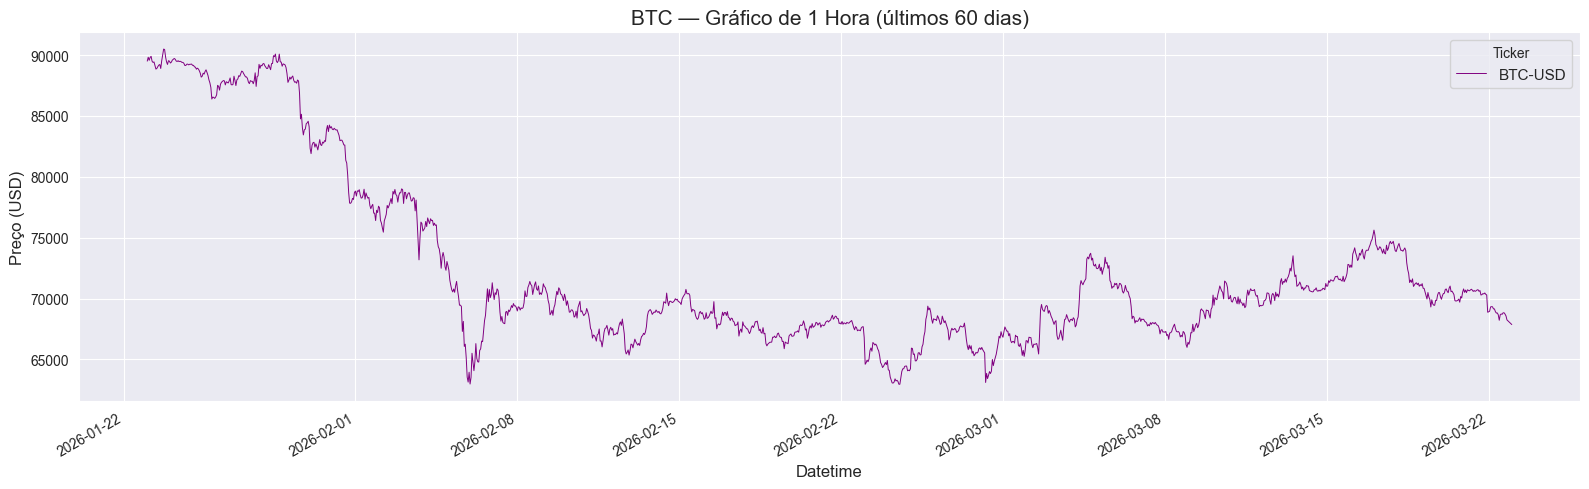

In [10]:
# ── Bloco 9: Download de dados intradiários ───────────────────────────────────
print('Baixando dados intradiários de 1 hora (últimos 60 dias)...')
df_intraday = yf.download('BTC-USD', period='60d', interval='1h',
                           auto_adjust=True, progress=False)

if df_intraday.empty:
    print('⚠️  Dados intradiários indisponíveis. Pulando análise intradiária.')
else:
    print(f'✅ {len(df_intraday):,} candles de 1h baixados.')
    fig, ax = plt.subplots(figsize=(16, 5))
    df_intraday['Close'].plot(ax=ax, color='purple', linewidth=0.7)
    ax.set_title('BTC — Gráfico de 1 Hora (últimos 60 dias)')
    ax.set_ylabel('Preço (USD)')
    plt.tight_layout()
    plt.show()

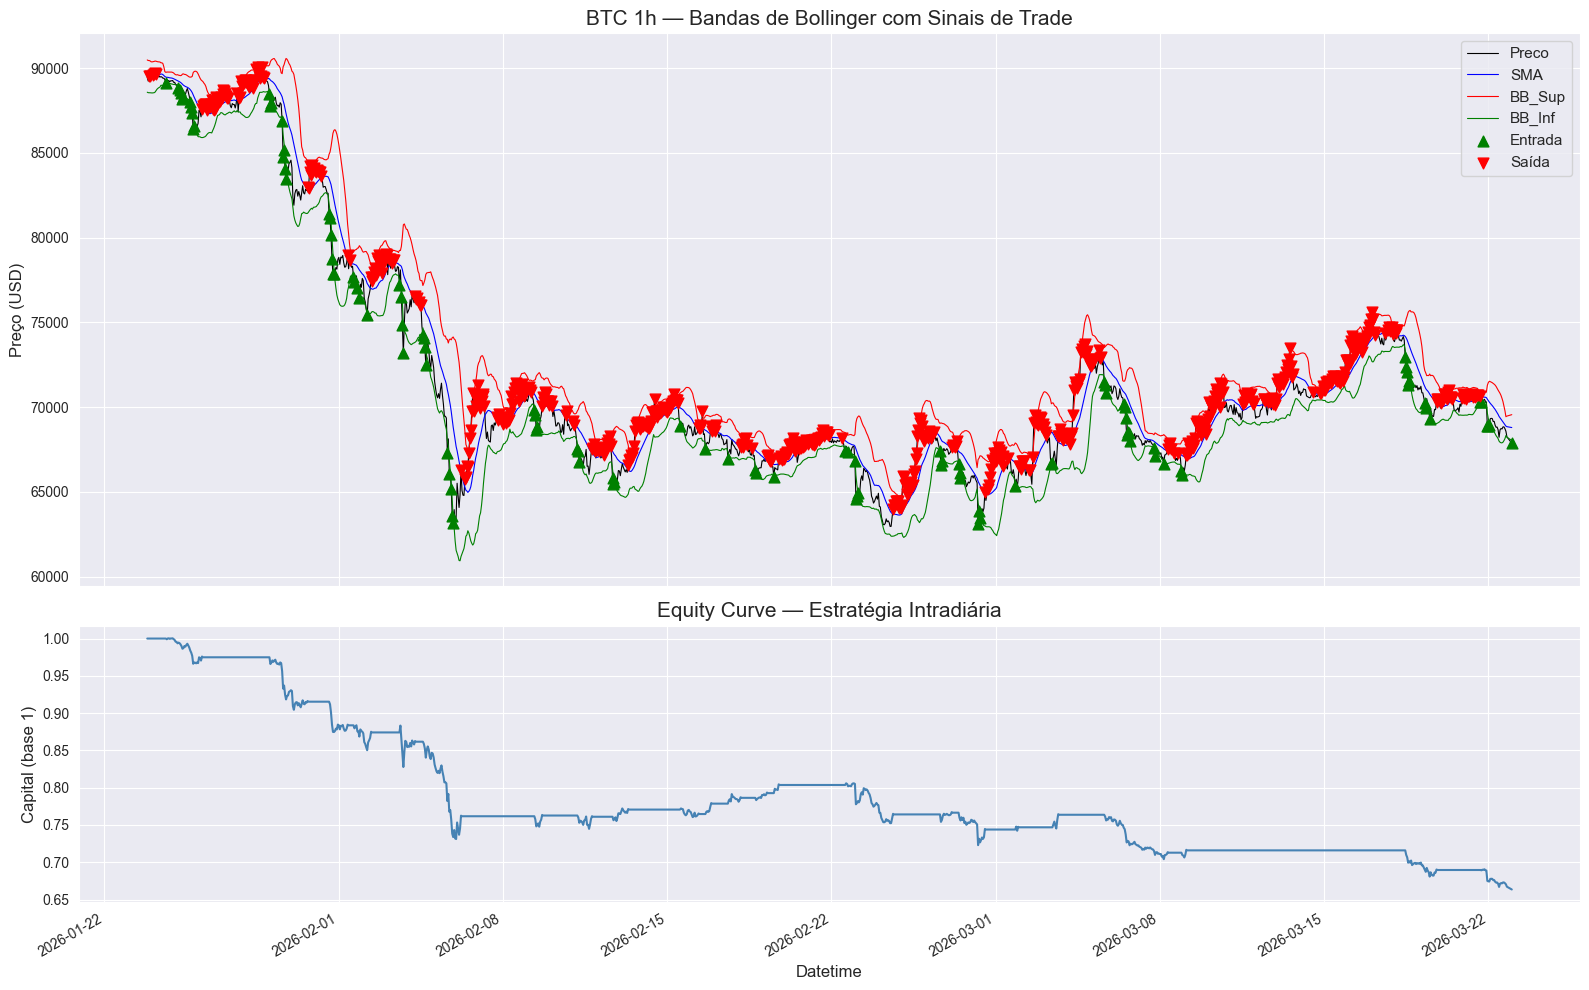


── Resultado Final da Estratégia Intradiária ──
  Retorno Total: 0.6635x  (Prejuízo)
  Nº de Entradas: 106
  Nº de Saídas:   623


In [11]:
# ── Bloco 10: Backtest Intradiário — Reversão à Média com Bollinger Bands ──────
if 'df_intraday' in dir() and not df_intraday.empty:

    BOLLINGER_WIN  = 20   # janela da média (horas)
    BOLLINGER_STD  = 2    # desvios padrão
    CUSTO_INTRADAY = 0.001

    df_bb = pd.DataFrame({'Preco': df_intraday['Close'].squeeze()})
    df_bb['SMA']      = df_bb['Preco'].rolling(BOLLINGER_WIN).mean()
    df_bb['StdDev']   = df_bb['Preco'].rolling(BOLLINGER_WIN).std()
    df_bb['BB_Sup']   = df_bb['SMA'] + BOLLINGER_STD * df_bb['StdDev']
    df_bb['BB_Inf']   = df_bb['SMA'] - BOLLINGER_STD * df_bb['StdDev']
    df_bb.dropna(inplace=True)

    # ── Sinal de cruzamento (vetorizado, sem loop) ────────────────────────────
    # Compra: preço cruza para BAIXO da banda inferior
    # Venda:  preço cruza para CIMA da média
    below_inf     = df_bb['Preco'] < df_bb['BB_Inf']
    below_inf_lag = below_inf.shift(1).fillna(False)
    above_sma     = df_bb['Preco'] > df_bb['SMA']
    above_sma_lag = above_sma.shift(1).fillna(False)

    df_bb['Sinal'] = 0
    df_bb.loc[ below_inf & ~below_inf_lag, 'Sinal'] =  1  # entrada
    df_bb.loc[ above_sma & ~above_sma_lag, 'Sinal'] = -1  # saída

    # Posição (long-only, fechamento no fim do dia UTC)
    df_bb['Posicao'] = (
        df_bb['Sinal']
        .replace(0, np.nan)
        .ffill()
        .fillna(0)
        .replace(-1, 0)
    )
    # Fecha posição no fim de cada dia (hora 23)
    fim_dia = df_bb.index.hour == 23
    df_bb.loc[fim_dia, 'Posicao'] = 0
    df_bb['Posicao'] = df_bb['Posicao'].shift(1).fillna(0)

    # Retornos
    df_bb['Ret_Hora']      = df_bb['Preco'].pct_change()
    df_bb['Custo']         = df_bb['Posicao'].diff().abs() * CUSTO_INTRADAY
    df_bb['Ret_Estrategia'] = df_bb['Ret_Hora'] * df_bb['Posicao'] - df_bb['Custo']
    df_bb.dropna(inplace=True)
    df_bb['Equity'] = (1 + df_bb['Ret_Estrategia']).cumprod()

    # Plot
    fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                             gridspec_kw={'height_ratios': [2, 1]})

    df_bb[['Preco','SMA','BB_Sup','BB_Inf']].plot(ax=axes[0],
        color=['black','blue','red','green'], linewidth=0.8)
    axes[0].set_title('BTC 1h — Bandas de Bollinger com Sinais de Trade')
    axes[0].set_ylabel('Preço (USD)')

    # Marca entradas e saídas
    entradas = df_bb[df_bb['Sinal'] == 1]
    saidas   = df_bb[df_bb['Sinal'] == -1]
    axes[0].scatter(entradas.index, entradas['Preco'], marker='^', color='green', s=60, zorder=5, label='Entrada')
    axes[0].scatter(saidas.index,   saidas['Preco'],   marker='v', color='red',   s=60, zorder=5, label='Saída')
    axes[0].legend()

    df_bb['Equity'].plot(ax=axes[1], color='steelblue')
    axes[1].set_title('Equity Curve — Estratégia Intradiária')
    axes[1].set_ylabel('Capital (base 1)')

    plt.tight_layout()
    plt.show()

    total_intra = df_bb['Equity'].iloc[-1]
    print(f'\n── Resultado Final da Estratégia Intradiária ──')
    print(f'  Retorno Total: {total_intra:.4f}x  ({"Lucro" if total_intra >= 1 else "Prejuízo"})')
    print(f'  Nº de Entradas: {(df_bb["Sinal"]==1).sum()}')
    print(f'  Nº de Saídas:   {(df_bb["Sinal"]==-1).sum()}')

## 8. Correlação Rolling: BTC vs S&P 500

> Análise nova: a correlação entre BTC e S&P 500 **não é estável no tempo**.
> Períodos de estresse de mercado tendem a elevar a correlação (risco de contágio).
> A janela de 90 dias captura essa dinâmica com mais fidelidade do que um único número.

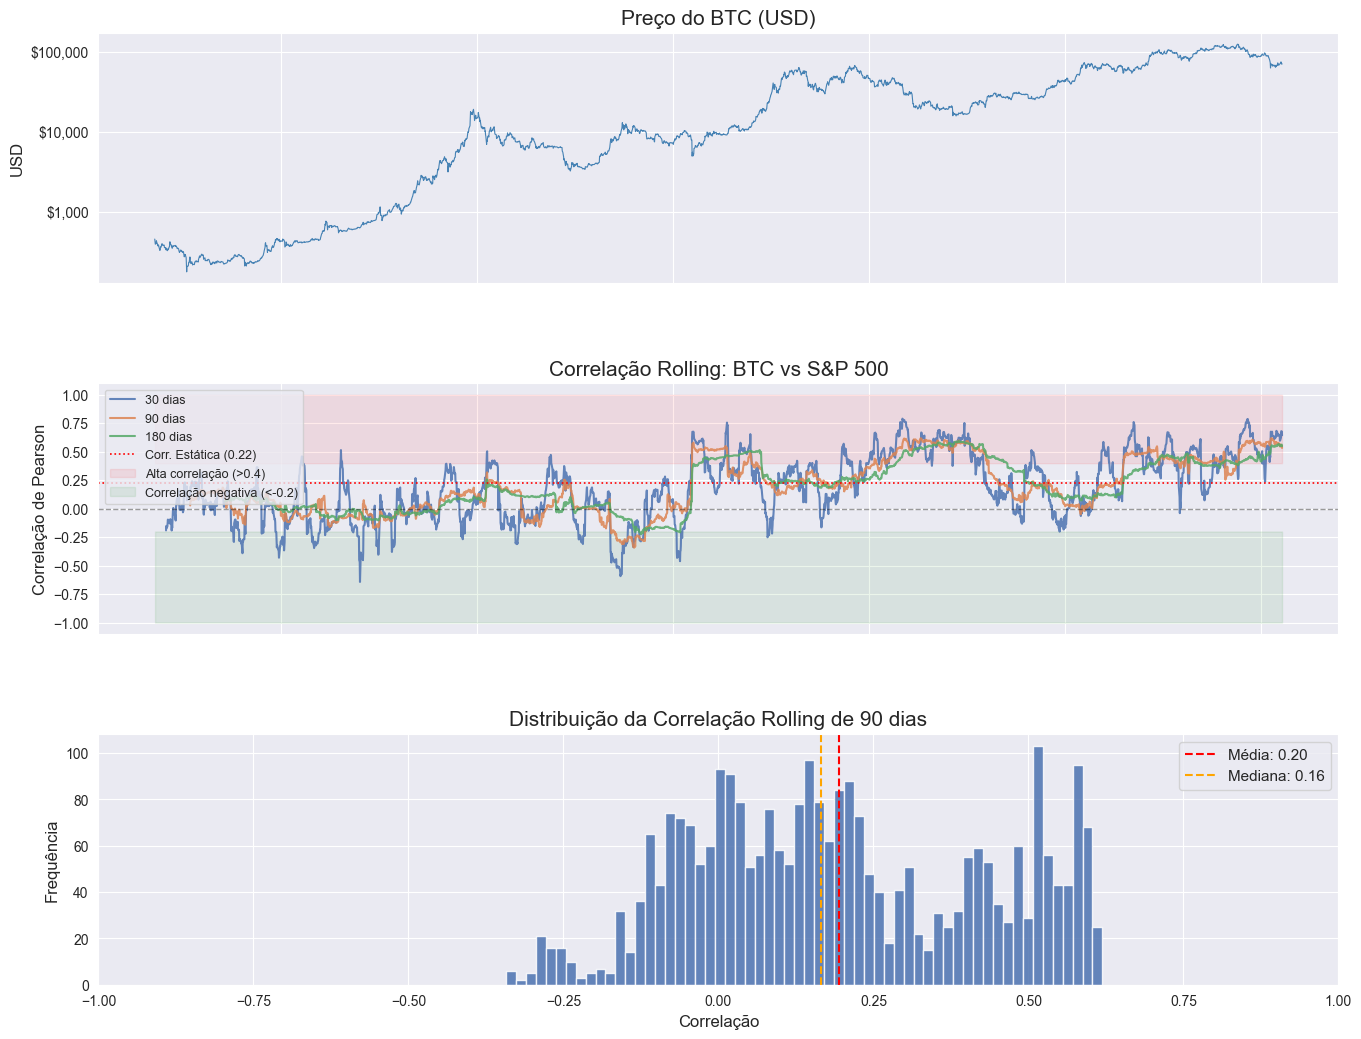


── Resumo: Correlação Rolling de 90 dias (BTC vs S&P 500) ──
  Correlação Estática (todo o período): 0.2237
  Média da correlação rolling 90d:      0.1953
  Mediana:                              0.1649
  Desvio Padrão:                        0.2342
  % do tempo com corr > 0.4:            26.1%
  % do tempo com corr < 0.0:            22.5%

  → A correlação varia de -0.34 a 0.62,
    indicando que o BTC NÃO é um hedge confiável e sua relação
    com o mercado tradicional muda substancialmente ao longo do tempo.


In [12]:
# ── Bloco 11: Correlação Rolling e Análise de Regimes ─────────────────────────

ROLLING_WINDOWS = [30, 90, 180]  # janelas em dias

# ── Correlações rolling ───────────────────────────────────────────────────────
corr_df = pd.DataFrame(index=returns.index)
for w in ROLLING_WINDOWS:
    corr_df[f'Corr_{w}d'] = (
        returns['BTC_ret']
        .rolling(w)
        .corr(returns['SP500_ret'])
    )

corr_static = returns['BTC_ret'].corr(returns['SP500_ret'])
corr_90     = corr_df['Corr_90d'].dropna()

# ── Plot principal ────────────────────────────────────────────────────────────
# Não usamos sharex=True para todos: o histograma tem eixo X próprio
# (valores de correlação -1..1), não datas
fig = plt.figure(figsize=(16, 14))
gs  = fig.add_gridspec(3, 1, hspace=0.4)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1], sharex=ax0)  # compartilha eixo X com ax0 (datas)
ax2 = fig.add_subplot(gs[2])              # eixo X independente (correlação -1..1)

# 1. Preço do BTC (contexto)
close['BTC'].plot(ax=ax0, color='steelblue', linewidth=0.8)
ax0.set_title('Preço do BTC (USD)')
ax0.set_ylabel('USD')
ax0.set_yscale('log')
ax0.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# 2. Correlação rolling
colors = ['#4C72B0', '#DD8452', '#55A868']
for col, color in zip(corr_df.columns, colors):
    corr_df[col].plot(ax=ax1, label=col.replace('Corr_','').replace('d',' dias'), color=color, alpha=0.85)
ax1.axhline(0,           color='black', linewidth=1,   linestyle='--', alpha=0.4)
ax1.axhline(corr_static, color='red',   linewidth=1.2, linestyle=':',  label=f'Corr. Estática ({corr_static:.2f})')
ax1.fill_between(corr_df.index,  0.4,  1.0, alpha=0.08, color='red',   label='Alta correlação (>0.4)')
ax1.fill_between(corr_df.index, -1.0, -0.2, alpha=0.08, color='green', label='Correlação negativa (<-0.2)')
ax1.set_title('Correlação Rolling: BTC vs S&P 500')
ax1.set_ylabel('Correlação de Pearson')
ax1.set_ylim(-1.1, 1.1)
ax1.legend(loc='upper left', fontsize=9)

# 3. Histograma — eixo X = valores de correlação (-1 a 1), independente de datas
ax2.hist(corr_90.values, bins=60, color='#4C72B0', edgecolor='white', alpha=0.85)
ax2.axvline(corr_90.mean(),   color='red',    linestyle='--', label=f'Média: {corr_90.mean():.2f}')
ax2.axvline(corr_90.median(), color='orange', linestyle='--', label=f'Mediana: {corr_90.median():.2f}')
ax2.set_title('Distribuição da Correlação Rolling de 90 dias')
ax2.set_xlabel('Correlação')
ax2.set_ylabel('Frequência')
ax2.set_xlim(-1, 1)
ax2.legend()

plt.show()

# ── Resumo estatístico ────────────────────────────────────────────────────────
print('\n── Resumo: Correlação Rolling de 90 dias (BTC vs S&P 500) ──')
print(f'  Correlação Estática (todo o período): {corr_static:.4f}')
print(f'  Média da correlação rolling 90d:      {corr_90.mean():.4f}')
print(f'  Mediana:                              {corr_90.median():.4f}')
print(f'  Desvio Padrão:                        {corr_90.std():.4f}')
print(f'  % do tempo com corr > 0.4:            {(corr_90 > 0.4).mean():.1%}')
print(f'  % do tempo com corr < 0.0:            {(corr_90 < 0.0).mean():.1%}')
print(f'\n  → A correlação varia de {corr_90.min():.2f} a {corr_90.max():.2f},')
print(f'    indicando que o BTC NÃO é um hedge confiável e sua relação')
print(f'    com o mercado tradicional muda substancialmente ao longo do tempo.')


---
## Conclusões

| Aspecto | Achado |
|---|---|
| **Volatilidade** | BTC apresenta volatilidade anualizada muito superior ao S&P 500, com caudas pesadas |
| **Tendência** | Estratégias de cruzamento de médias atuam como filtros de regime, reduzindo exposição em bearmarkets |
| **Risco vs Retorno** | Buy & Hold supera em retorno absoluto; estratégias sistemáticas têm Sharpe/Sortino comparável com menor drawdown |
| **Trailing Stop** | Reduz o drawdown máximo significativamente ao custo de menor retorno total |
| **Correlação** | A correlação BTC-S&P500 é dinâmica: pode ser positiva, zero ou negativa dependendo do período |
| **Custos** | Custos de transação penalizam fortemente estratégias de alta frequência |

> ⚠️ **Aviso:** Este notebook é exclusivamente para fins educacionais e de pesquisa quantitativa. Não constitui recomendação de investimento.